# Predicting Health Outcomes Using Environmental, Socioeconomic and Digital Inclusion Data in Sunderland

**Full machine learning pipeline**: data loading & cleaning → exploratory data analysis → model
building (Linear Regression, Random Forest, XGBoost) → evaluation (MAE, RMSE, R²) → feature
importance → geographic visualisation.

### Data sources & scope
| Source | Geography | Role |
|---|---|---|
| `raw_data/all-datasets.csv` (ONS *Explore Local Statistics*) | Local Authority (England, ~330 areas) | **National model**: predictors + target (preventable CVD mortality) |
| `raw_data/File_7_IoD2025_...csv` (English Indices of Deprivation 2025) | LSOA (England-wide → filtered to Sunderland's 185 LSOAs) | **Sunderland deep-dive**: predictors + target (Health Deprivation score) |
| `raw_data/SUN2_2024/2025/2026.csv` (UK-AIR Sunderland Silksworth station) | Single monitoring point | Local environmental context (air quality time trend) |

**Why two models instead of one ward-level model?** Only the deprivation index is genuinely
available at LSOA level for Sunderland. The ONS digital-inclusion/environmental indicators are
published at Local Authority level (one figure for the whole of Sunderland), and the air quality
file is a single sensor. Rather than fabricate spatial detail the source data doesn't contain,
this notebook builds:

1. A **national LA-level model** — real cross-sectional variation across ~270 English
   authorities, using the full range of environmental + socioeconomic + digital-inclusion
   indicators, with Sunderland highlighted throughout.
2. A **Sunderland LSOA-level model** — real within-Sunderland ward detail, using the one
   dataset that *is* published at that resolution.

> **Note on `all-datasets.csv`**: this source file is ~108MB and is not bundled with this
> notebook. If you place your own copy in `raw_data/`, Section 1.1 will rebuild the national
> dataset from scratch. Otherwise it automatically falls back to the pre-built cache in
> `cache/national_la_dataset.csv` (identical output, just skips the 108MB parse for speed).


## 0. Setup

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
RANDOM_STATE = 42

RAW_DIR = "raw_data"
CACHE_DIR = "cache"
BOUNDARY_DIR = "boundaries"
os.makedirs(CACHE_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Data Loading & Cleaning

### 1.1 National Local-Authority dataset (from ONS Explore Local Statistics)

We take the **most recent available value** of the target and each predictor indicator for
every English Local Authority, and pivot the long-format ONS export into one row per area.

- **Target (Y):** Preventable cardiovascular mortality rate (deaths per 100,000, age-standardised)
- **Predictors (X):** socioeconomic (income, employment, education, poverty, housing),
  environmental (emissions, air pollution regulation, domestic energy use), digital inclusion
  (4G/5G coverage, broadband), and lifestyle/demographic controls (obesity, smoking, age, density)

We restrict to **E06 (unitary), E07 (district), E08 (metropolitan borough) and E09 (London
borough)** codes and deliberately **exclude E10 (county councils)**, since county areas are
simply aggregates of their constituent E07 districts already in the sample — including both
would double-count the same underlying geography.

In [3]:
LA_PREFIXES = ("E06", "E07", "E08", "E09")

TARGET_INDICATOR = "Preventable cardiovascular mortality (England)"
TARGET_COL = "cvd_mortality_rate"

PREDICTOR_INDICATORS = {
    
    # Socioeconomic
    "Employment rate (Great Britain)": "employment_rate",
    "Economic inactivity rate (Great Britain)": "econ_inactivity_rate",
    "Gross disposable household income per head": "gdhi_per_head",
    "Children in relative poverty after housing costs": "child_poverty_pct",
    "No qualifications": "no_qualifications_pct",
    "Level 3 or above qualifications (Great Britain)": "level3_plus_qual_pct",
    "Fuel poverty (England)": "fuel_poverty_pct",
    "Housing affordability ratio (residence-based)": "housing_affordability_ratio",
    "Average house price": "avg_house_price",
    
    # Environmental
    "Greenhouse gas emissions": "ghg_emissions",
    "Air pollution regulating": "air_pollution_regulating",
    "Domestic gas consumption": "domestic_gas_consumption",
    "Domestic electricity consumption": "domestic_elec_consumption",
    
    # Digital inclusion
    "4G coverage": "coverage_4g_pct",
    "5G coverage": "coverage_5g_pct",
    "Gigabit capable broadband": "gigabit_broadband_pct",
    "Premises below 30Mbps": "premises_below_30mbps_pct",
    
    # Lifestyle / demographic controls
    "Adult obesity prevalence": "adult_obesity_pct",
    "Cigarette smokers": "cigarette_smokers_pct",
    "Population density": "population_density",
    "Median age": "median_age",
    "Job density": "job_density",
}
NAT_FEATURES = list(PREDICTOR_INDICATORS.values())


def latest_value_per_area(df, indicator):
    """Return the most recent non-null value of `indicator` for each LA."""
    sub = df[df["indicator"] == indicator].copy()
    sub = sub[sub["areacd"].str.startswith(LA_PREFIXES, na=False)]
    if "sex" in sub.columns and sub["sex"].notna().any():
        sub = sub[sub["sex"].isin(["All", "Persons"]) | sub["sex"].isna()]
    if "age" in sub.columns and sub["age"].notna().any():
        sub = sub[sub["age"].isna()]
    sub["value"] = pd.to_numeric(sub["value"], errors="coerce")
    sub = sub.dropna(subset=["value"]).sort_values("period")
    return sub.groupby("areacd", as_index=False).last()[["areacd", "areanm", "period", "value"]]


raw_path = os.path.join("all-datasets.csv")
cache_path = os.path.join("national_la_dataset.csv")

if os.path.exists(raw_path):
    print("Building national dataset from raw all-datasets.csv (this can take ~30s)...")
    df_long = pd.read_csv(raw_path, dtype=str)

    target_df = latest_value_per_area(df_long, TARGET_INDICATOR)
    target_df = target_df.rename(columns={"value": TARGET_COL, "period": f"{TARGET_COL}_period"})
    national = target_df[["areacd", "areanm", f"{TARGET_COL}_period", TARGET_COL]].copy()

    for indicator, colname in PREDICTOR_INDICATORS.items():
        pred_df = latest_value_per_area(df_long, indicator).rename(columns={"value": colname})
        national = national.merge(pred_df[["areacd", colname]], on="areacd", how="left")

    national = national.sort_values("areanm").reset_index(drop=True)
    national.to_csv(cache_path, index=False)
    print(f"Built {len(national)} LA rows from raw data and refreshed cache.")
else:
    print(f"'{raw_path}' not found -> loading pre-built cache instead.")
    national = pd.read_csv(cache_path)
    print(f"Loaded {len(national)} LA rows from cache.")

print(f"\nComplete rows (target + all predictors non-null): "
      f"{national.dropna(subset=[TARGET_COL] + NAT_FEATURES).shape[0]} / {len(national)}")
national.head()

Building national dataset from raw all-datasets.csv (this can take ~30s)...
Built 292 LA rows from raw data and refreshed cache.

Complete rows (target + all predictors non-null): 268 / 292


,areacd,areanm,cvd_mortality_rate_period,cvd_mortality_rate,employment_rate,econ_inactivity_rate,gdhi_per_head,child_poverty_pct,no_qualifications_pct,level3_plus_qual_pct,...,domestic_elec_consumption,coverage_4g_pct,coverage_5g_pct,gigabit_broadband_pct,premises_below_30mbps_pct,adult_obesity_pct,cigarette_smokers_pct,population_density,median_age,job_density
0,E07000223,Adur,2022-01-01/P3Y,22.906762,77.6,22.4,23470,21.327757,NaN,66.9,...,2505.95,99.81,99.91,95.4,0.9,24.92315,10.1,1542,45.0,0.62
1,E07000032,Amber Valley,2022-01-01/P3Y,29.593365,78.0,19.2,22715,23.376142,3.7,62.8,...,2439.60,99.97,99.90,89.2,1.5,29.01824,12.5,491,45.0,0.69
2,E07000224,Arun,2022-01-01/P3Y,25.991505,81.2,13.0,25129,27.326234,4.2,71.1,...,2468.35,99.44,93.24,82.3,1.2,36.47196,10.8,770,49.0,0.65
3,E07000170,Ashfield,2022-01-01/P3Y,42.823186,64.4,31.3,18772,29.799163,10.6,53.5,...,2397.20,100.00,99.89,97.0,0.6,28.15522,10.8,1183,42.0,0.77
4,E07000105,Ashford,2022-01-01/P3Y,21.581190,68.1,28.3,25687,22.867922,11.5,63.1,...,2692.45,99.83,95.32,76.0,5.6,24.19801,12.0,243,41.0,0.90


In [4]:
len(national)

292

In [5]:
len(raw_path)

16

In [36]:
all_data = pd.read_csv('all-datasets.csv')
all_data.head()

,indicator,areacd,areanm,period,sex,age,value,lci_95,uci_95,status
0,Total population,E06000001,Hartlepool,1991-06-30,NaN,NaN,91058.0,NaN,NaN,NaN
1,Total population,E06000001,Hartlepool,1992-06-30,NaN,NaN,91225.0,NaN,NaN,NaN
2,Total population,E06000001,Hartlepool,1993-06-30,NaN,NaN,91081.0,NaN,NaN,NaN
3,Total population,E06000001,Hartlepool,1994-06-30,NaN,NaN,91027.0,NaN,NaN,NaN
4,Total population,E06000001,Hartlepool,1995-06-30,NaN,NaN,90673.0,NaN,NaN,NaN


In [37]:
len(all_data)

1320494

In [38]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320494 entries, 0 to 1320493
Data columns (total 10 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   indicator  1320494 non-null  object 
 1   areacd     1320494 non-null  object 
 2   areanm     1320494 non-null  object 
 3   period     1320494 non-null  object 
 4   sex        752328 non-null   object 
 5   age        752328 non-null   object 
 6   value      1311871 non-null  float64
 7   lci_95     118187 non-null   float64
 8   uci_95     118187 non-null   float64
 9   status     9900 non-null     object 
dtypes: float64(3), object(7)
memory usage: 100.7+ MB


In [6]:
national.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
cvd_mortality_rate,292.0,29.52,8.10,15.56,22.99,28.56,34.49,54.39
employment_rate,292.0,76.86,6.09,53.00,73.10,77.60,81.20,91.70
econ_inactivity_rate,292.0,20.42,5.56,6.70,16.50,19.95,24.22,42.00
gdhi_per_head,292.0,25812.99,8492.80,16067.00,21166.25,24217.00,28110.00,110651.00
child_poverty_pct,292.0,24.91,7.62,10.62,19.24,24.18,29.71,50.34
no_qualifications_pct,274.0,6.55,3.28,1.50,4.03,5.80,8.40,19.60
level3_plus_qual_pct,292.0,66.90,9.37,41.30,60.58,66.60,73.80,89.10
fuel_poverty_pct,290.0,9.70,1.73,5.56,8.34,9.72,10.85,14.77
housing_affordability_ratio,290.0,8.12,2.35,3.86,6.39,7.92,9.50,21.87
avg_house_price,290.0,330915.86,143927.87,130271.00,230169.00,301830.00,402971.50,1250149.00


### 1.2 Sunderland LSOA-level dataset (from IoD2025)

We filter the England-wide English Indices of Deprivation 2025 file down to Sunderland
(Local Authority code `E08000024`) and select the domain scores we need.

- **Target (Y):** Health Deprivation & Disability score — a validated composite of years of
  potential life lost, illness/disability, acute morbidity and mood/anxiety disorders. Higher =
  worse health. This is one of seven domains combined into the overall Index of Multiple
  Deprivation, so it is standard public-health/JSNA practice to treat it as an outcome and the
  other domains as explanatory socioeconomic predictors.
- **Predictors (X):** Income, Employment, Education/Skills/Training, Crime, Barriers to Housing
  & Services, Living Environment domain scores, plus population age structure.

In [9]:
SUNDERLAND_LAD_CODE = "E08000024"

IOD_COLS = {
    "LSOA code (2021)": "lsoa_code",
    "LSOA name (2021)": "lsoa_name",
    "Index of Multiple Deprivation (IMD) Score": "imd_score",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile",
    "Health Deprivation and Disability Score": "health_deprivation_score",
    "Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs)": "health_deprivation_decile",
    "Income Score (rate)": "income_score",
    "Employment Score (rate)": "employment_score",
    "Education, Skills and Training Score": "education_score",
    "Crime Score": "crime_score",
    "Barriers to Housing and Services Score": "housing_barriers_score",
    "Living Environment Score": "living_environment_score",
    "Indoors Sub-domain Score": "indoors_subdomain_score",
    "Outdoors Sub-domain Score": "outdoors_subdomain_score",
    "Income Deprivation Affecting Children Index (IDACI) Score (rate)": "idaci_score",
    "Income Deprivation Affecting Older People (IDAOPI) Score (rate)": "idaopi_score",
    "Total population: mid 2022": "total_population",
    "Dependent Children aged 0-15: mid 2022": "population_0_15",
    "Older population aged 60 and over: mid 2022": "population_60_plus",
    "Working age population 18-66 (for use with Employment Deprivation Domain): mid 2022": "population_working_age",
}

iod_path = os.path.join("File_7_IoD2025_All_Ranks_Scores_Deciles_Population_Denominators.csv")
df_iod = pd.read_csv(iod_path, dtype={"LSOA code (2021)": str, "Local Authority District code (2024)": str})

sunderland = df_iod[df_iod["Local Authority District code (2024)"] == SUNDERLAND_LAD_CODE].copy()
sunderland = sunderland[list(IOD_COLS.keys())].rename(columns=IOD_COLS)

sunderland["pct_population_0_15"] = sunderland["population_0_15"] / sunderland["total_population"] * 100
sunderland["pct_population_60_plus"] = sunderland["population_60_plus"] / sunderland["total_population"] * 100
sunderland = sunderland.sort_values("lsoa_code").reset_index(drop=True)

SUN_FEATURES = ["income_score", "employment_score", "education_score", "crime_score",
                 "housing_barriers_score", "living_environment_score",
                 "pct_population_0_15", "pct_population_60_plus"]
SUN_TARGET = "health_deprivation_score"

print(f"Sunderland LSOAs: {len(sunderland)}")
sunderland.head()

Sunderland LSOAs: 185


,lsoa_code,lsoa_name,imd_score,imd_decile,health_deprivation_score,health_deprivation_decile,income_score,employment_score,education_score,crime_score,...,indoors_subdomain_score,outdoors_subdomain_score,idaci_score,idaopi_score,total_population,population_0_15,population_60_plus,population_working_age,pct_population_0_15,pct_population_60_plus
0,E01008693,Sunderland 008A,39.321,2,1.568,1,0.346,0.238,40.163,0.959,...,0.205,0.626,0.511,0.236,1471,259,399,926,17.607070,27.124405
1,E01008694,Sunderland 008B,41.154,2,1.539,1,0.418,0.266,38.285,0.872,...,-0.169,-0.273,0.672,0.387,1376,251,328,880,18.241279,23.837209
2,E01008695,Sunderland 008C,39.530,2,1.240,1,0.401,0.272,47.859,0.195,...,-0.151,-0.007,0.546,0.330,1470,304,314,950,20.680272,21.360544
3,E01008696,Sunderland 008D,15.238,6,0.614,3,0.158,0.126,12.702,-0.068,...,-0.773,-0.573,0.192,0.165,1194,167,330,843,13.986600,27.638191
4,E01008697,Sunderland 008E,38.558,2,1.518,1,0.381,0.226,48.058,0.786,...,-0.206,-0.256,0.423,0.449,1362,206,492,761,15.124816,36.123348


In [10]:
sunderland.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
imd_score,185.0,32.749,18.678,4.462,16.028,30.881,46.758,83.195
imd_decile,185.0,3.768,2.765,1.000,1.000,3.000,6.000,10.000
health_deprivation_score,185.0,1.052,0.683,-0.421,0.550,1.072,1.560,2.626
health_deprivation_decile,185.0,2.314,1.588,1.000,1.000,2.000,3.000,7.000
income_score,185.0,0.307,0.170,0.037,0.150,0.310,0.443,0.660
employment_score,185.0,0.210,0.103,0.041,0.126,0.198,0.276,0.535
education_score,185.0,31.574,20.574,2.152,13.337,29.670,48.542,87.782
crime_score,185.0,0.439,0.835,-2.349,-0.122,0.519,1.053,2.641
housing_barriers_score,185.0,14.528,4.468,5.340,11.522,14.393,17.371,26.903
living_environment_score,185.0,20.864,17.518,1.273,8.557,15.128,27.203,73.631


### 1.3 Air quality data (Sunderland Silksworth monitoring station)

Hourly readings from the **UK-AIR Sunderland Silksworth** station (Jan 2024 – Aug 2026),
aggregated to daily and monthly means. This is a single fixed monitoring point, not a spatial
dataset, so it is used for local environmental context rather than as a model predictor.

In [ ]:
"SUN2_2024.csv", "SUN2_2025.csv", "SUN2_2026.csv"

In [53]:
sun = pd.read_csv("SUN2_2024.csv", sep=";", skipinitialspace=True)
sun.head()

,Data supplied by UK-AIR on 25/3/2025
0,All Data GMT hour ending
1,"Status: R =Ratified P=Provisional,P*=As supplied"
2,",,Sunderland Silksworth,,,,,,,,,,,,,,,,,,,,,,,"
3,"Date,time,""PM<sub>10</sub> particulate matter ..."
4,"01-01-2024,01:00,7.350,R,ugm-3 (FIDAS),0.27733..."


In [54]:
len(sun)

8788

In [12]:
COLNAMES = [
    "date", "time", "pm10", "pm10_status", "pm10_unit", "no", "no_status", "no_unit",
    "no2", "no2_status", "no2_unit", "nox", "nox_status", "nox_unit",
    "ozone", "ozone_status", "ozone_unit", "pm25", "pm25_status", "pm25_unit",
]

def load_air_quality_file(path):
    df = pd.read_csv(path, skiprows=5, header=None, names=COLNAMES)
    df = df.dropna(how="all")
    for c in ["pm10", "no", "no2", "nox", "ozone", "pm25"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["time"] = df["time"].replace("24:00", "00:00")
    df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], format="%d-%m-%Y %H:%M", errors="coerce")
    return df

aq_files = [os.path.join(f) for f in ["SUN2_2024.csv", "SUN2_2025.csv", "SUN2_2026.csv"]]
aq = pd.concat([load_air_quality_file(f) for f in aq_files], ignore_index=True)
aq = aq.dropna(subset=["datetime"]).sort_values("datetime")

pollutants = ["pm10", "no", "no2", "nox", "ozone", "pm25"]
aq["date_only"] = aq["datetime"].dt.date
aq_daily = aq.groupby("date_only")[pollutants].mean().reset_index().rename(columns={"date_only": "date"})

aq["month"] = aq["datetime"].dt.to_period("M").astype(str)
aq_monthly = aq.groupby("month")[pollutants].mean().reset_index()

print(f"Hourly readings: {len(aq)} ({aq['datetime'].min()} to {aq['datetime'].max()})")
print(f"Daily summary: {len(aq_daily)} days | Monthly summary: {len(aq_monthly)} months")
aq_daily.head()

Hourly readings: 23088 (2024-01-01 00:00:00 to 2026-08-19 23:00:00)
Daily summary: 962 days | Monthly summary: 32 months


,date,pm10,no,no2,nox,ozone,pm25
0,2024-01-01,7.292708,3.740178,10.811175,16.546035,53.144523,4.316042
1,2024-01-02,12.592708,6.596162,21.754121,31.868095,43.773048,8.411958
2,2024-01-03,7.280208,13.079230,30.990932,51.045471,24.587995,5.450083
3,2024-01-04,5.985417,4.690128,16.039608,23.231035,40.020716,4.393708
4,2024-01-05,11.105208,8.709416,23.852979,37.207230,26.214352,6.502625


In [41]:
aq.head()

,date,time,pm10,pm10_status,pm10_unit,no,no_status,no_unit,no2,no2_status,...,nox_unit,ozone,ozone_status,ozone_unit,pm25,pm25_status,pm25_unit,datetime,date_only,month
23,01-01-2024,00:00,10.125,R,ugm-3 (FIDAS),0.68341,R,ugm-3,1.58155,R,...,ugm-3,79.97768,R,ugm-3,4.552,R,ugm-3 (Ref.eq),2024-01-01 00:00:00,2024-01-01,2024-01
0,01-01-2024,01:00,7.350,R,ugm-3 (FIDAS),0.27733,R,ugm-3,4.49534,R,...,ugm-3,49.75945,R,ugm-3,5.684,R,ugm-3 (Ref.eq),2024-01-01 01:00:00,2024-01-01,2024-01
1,01-01-2024,02:00,5.300,R,ugm-3 (FIDAS),0.31694,R,ugm-3,3.32746,R,...,ugm-3,49.59315,R,ugm-3,4.151,R,ugm-3 (Ref.eq),2024-01-01 02:00:00,2024-01-01,2024-01
2,01-01-2024,03:00,5.250,R,ugm-3 (FIDAS),0.35656,R,ugm-3,2.91305,R,...,ugm-3,51.43917,R,ugm-3,3.962,R,ugm-3 (Ref.eq),2024-01-01 03:00:00,2024-01-01,2024-01
3,01-01-2024,04:00,4.700,R,ugm-3 (FIDAS),0.35656,R,ugm-3,2.91305,R,...,ugm-3,56.02928,R,ugm-3,3.278,R,ugm-3 (Ref.eq),2024-01-01 04:00:00,2024-01-01,2024-01


In [42]:
len(aq)

23088

In [43]:
aq.isnull().sum()

date               0
time               0
pm10              24
pm10_status       24
pm10_unit         24
no              1056
no_status       1056
no_unit         1056
no2             1056
no2_status      1056
no2_unit        1056
nox             1057
nox_status      1057
nox_unit        1057
ozone           1088
ozone_status    1088
ozone_unit      1088
pm25              24
pm25_status       24
pm25_unit         24
datetime           0
date_only          0
month              0
dtype: int64

In [44]:
aq_monthly.head()

,month,pm10,no,no2,nox,ozone,pm25
0,2024-01,8.156039,3.558077,12.361779,17.817419,56.595425,4.820563
1,2024-02,8.932507,4.586372,11.754509,18.786848,55.787809,5.406055
2,2024-03,16.276470,3.966510,11.967471,18.049367,60.456286,10.580721
3,2024-04,9.148889,2.259069,8.222600,11.686457,72.585690,5.007714
4,2024-05,16.288810,3.020892,11.307239,15.939207,63.706165,10.395972


In [45]:
aq_daily.head()

,date,pm10,no,no2,nox,ozone,pm25
0,2024-01-01,7.292708,3.740178,10.811175,16.546035,53.144523,4.316042
1,2024-01-02,12.592708,6.596162,21.754121,31.868095,43.773048,8.411958
2,2024-01-03,7.280208,13.079230,30.990932,51.045471,24.587995,5.450083
3,2024-01-04,5.985417,4.690128,16.039608,23.231035,40.020716,4.393708
4,2024-01-05,11.105208,8.709416,23.852979,37.207230,26.214352,6.502625


## 2. Exploratory Data Analysis

### 2.1 National dataset

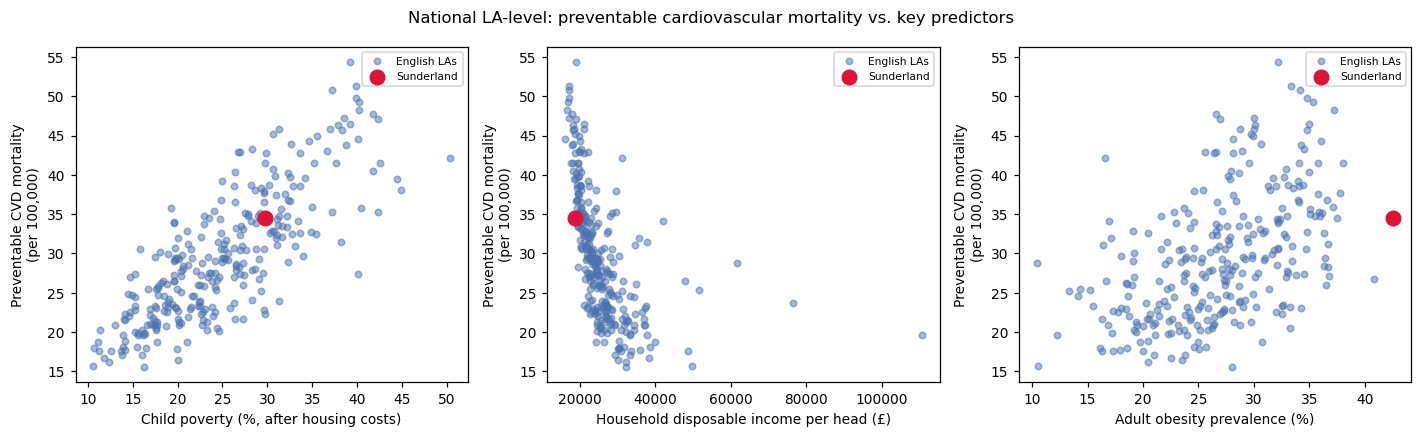

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, label in zip(
    axes,
    ["child_poverty_pct", "gdhi_per_head", "adult_obesity_pct"],
    ["Child poverty (%, after housing costs)", "Household disposable income per head (£)", "Adult obesity prevalence (%)"],
):
    ax.scatter(national[col], national[TARGET_COL], alpha=0.5, s=18, color="#4C72B0", label="English LAs")
    sund = national[national["areanm"] == "Sunderland"]
    ax.scatter(sund[col], sund[TARGET_COL], color="crimson", s=90, zorder=5, label="Sunderland")
    ax.set_xlabel(label)
    ax.set_ylabel("Preventable CVD mortality\n(per 100,000)")
    ax.legend(fontsize=7)
fig.suptitle("National LA-level: preventable cardiovascular mortality vs. key predictors")
fig.tight_layout()
plt.show()

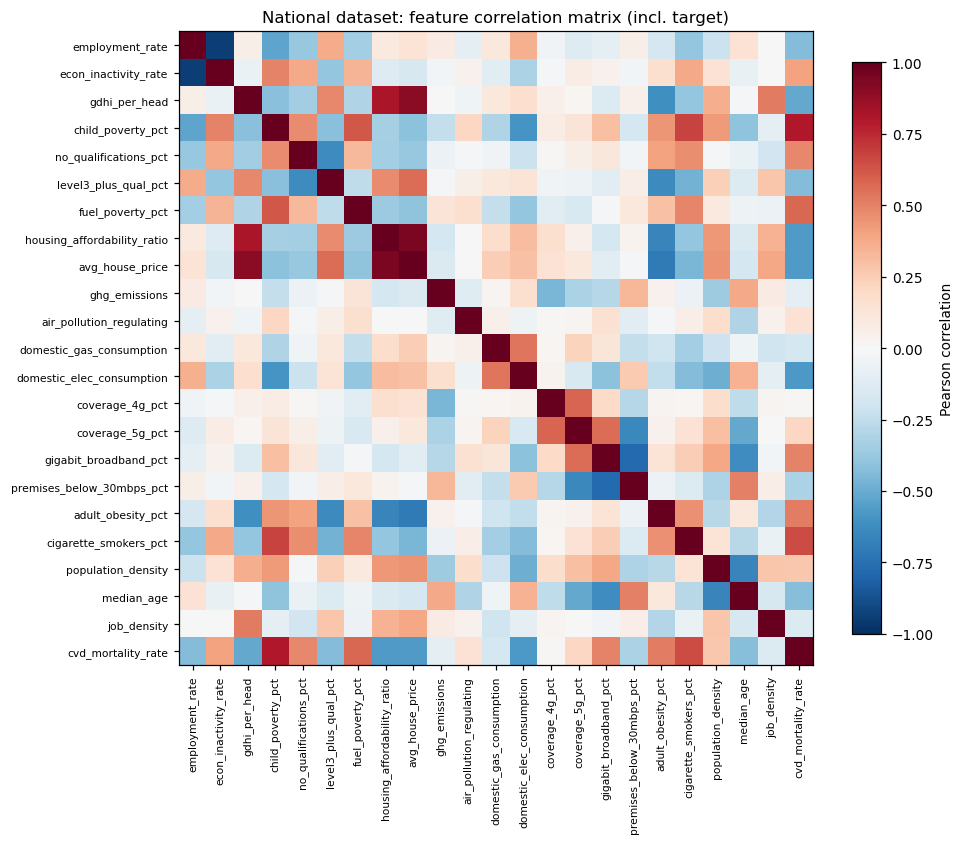

cvd_mortality_rate             1.000000
child_poverty_pct              0.801667
cigarette_smokers_pct          0.651724
fuel_poverty_pct               0.573900
adult_obesity_pct              0.508800
gigabit_broadband_pct          0.498506
no_qualifications_pct          0.479499
econ_inactivity_rate           0.404842
population_density             0.266097
coverage_5g_pct                0.208200
air_pollution_regulating       0.144434
coverage_4g_pct                0.009668
ghg_emissions                 -0.098814
job_density                   -0.136483
domestic_gas_consumption      -0.175603
premises_below_30mbps_pct     -0.316603
median_age                    -0.429555
employment_rate               -0.431875
level3_plus_qual_pct          -0.432945
gdhi_per_head                 -0.510132
housing_affordability_ratio   -0.563695
avg_house_price               -0.566462
domestic_elec_consumption     -0.576878
Name: cvd_mortality_rate, dtype: float64

In [14]:
nat_corr = national[NAT_FEATURES + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(nat_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(nat_corr.columns))); ax.set_xticklabels(nat_corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(nat_corr.columns))); ax.set_yticklabels(nat_corr.columns, fontsize=7)
fig.colorbar(im, shrink=0.8, label="Pearson correlation")
ax.set_title("National dataset: feature correlation matrix (incl. target)")
fig.tight_layout()
plt.show()

nat_corr[TARGET_COL].sort_values(ascending=False)

### 2.2 Sunderland LSOA dataset

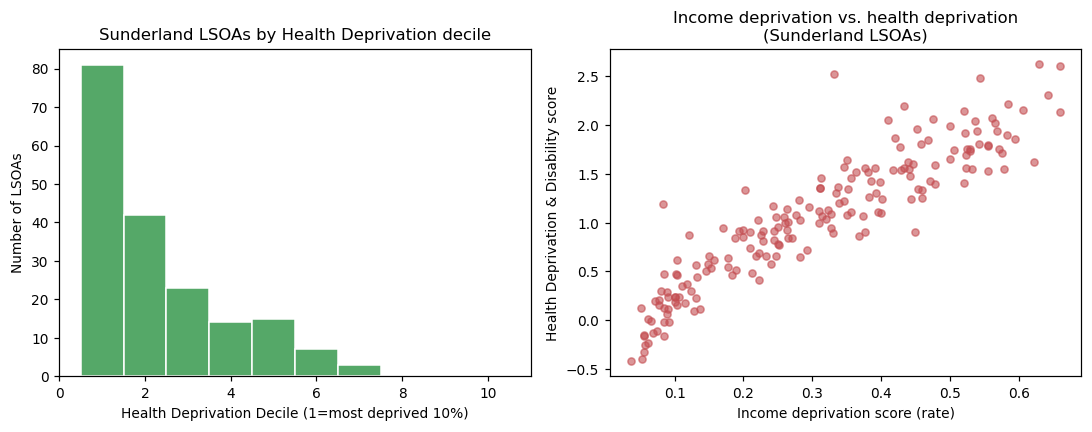

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(sunderland["health_deprivation_decile"], bins=range(1, 12), align="left",
             color="#55A868", edgecolor="white")
axes[0].set_xlabel("Health Deprivation Decile (1=most deprived 10%)")
axes[0].set_ylabel("Number of LSOAs")
axes[0].set_title("Sunderland LSOAs by Health Deprivation decile")

axes[1].scatter(sunderland["income_score"], sunderland["health_deprivation_score"],
                 alpha=0.6, s=22, color="#C44E52")
axes[1].set_xlabel("Income deprivation score (rate)")
axes[1].set_ylabel("Health Deprivation & Disability score")
axes[1].set_title("Income deprivation vs. health deprivation\n(Sunderland LSOAs)")
fig.tight_layout()
plt.show()

In [16]:
sun_corr = sunderland[SUN_FEATURES + [SUN_TARGET]].corr()
sun_corr[SUN_TARGET].sort_values(ascending=False)

health_deprivation_score    1.000000
employment_score            0.920905
income_score                0.915367
education_score             0.876021
crime_score                 0.773931
pct_population_0_15         0.419236
housing_barriers_score      0.397942
living_environment_score    0.093316
pct_population_60_plus     -0.451088
Name: health_deprivation_score, dtype: float64

### 2.3 Air quality trend

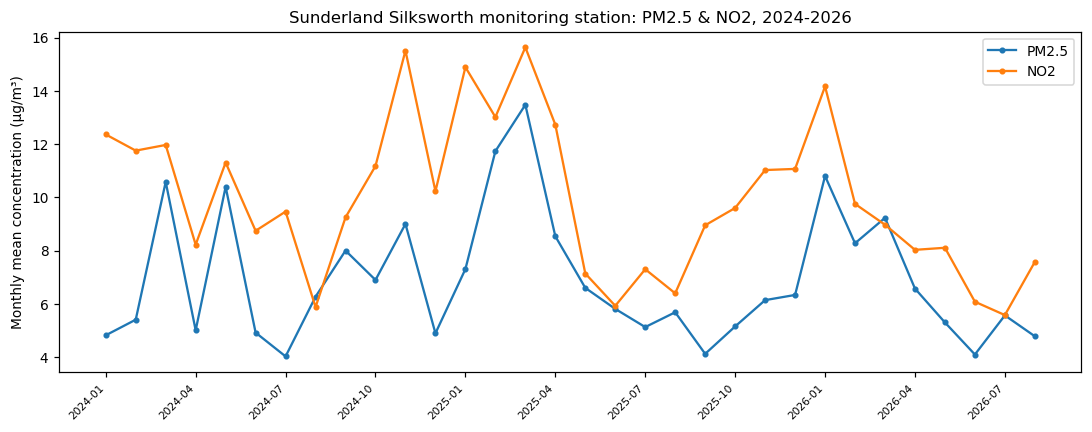

Mean PM2.5: 6.92 µg/m³  (WHO interim target 3, annual: 15)
Mean NO2:   9.98 µg/m³  (UK annual objective: 40)
Days PM2.5 > 15 µg/m³: 77 / 962


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(aq_monthly["month"], aq_monthly["pm25"], marker="o", ms=3, label="PM2.5")
ax.plot(aq_monthly["month"], aq_monthly["no2"], marker="o", ms=3, label="NO2")
ax.set_xticks(range(0, len(aq_monthly), 3))
ax.set_xticklabels(aq_monthly["month"][::3], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Monthly mean concentration (µg/m³)")
ax.set_title("Sunderland Silksworth monitoring station: PM2.5 & NO2, 2024-2026")
ax.legend()
fig.tight_layout()
plt.show()

print("Mean PM2.5:", round(aq_daily["pm25"].mean(), 2), "µg/m³  (WHO interim target 3, annual: 15)")
print("Mean NO2:  ", round(aq_daily["no2"].mean(), 2), "µg/m³  (UK annual objective: 40)")
print(f"Days PM2.5 > 15 µg/m³: {(aq_daily['pm25']>15).sum()} / {len(aq_daily)}")

## 3. Machine Learning Modelling

For each task we compare **Linear Regression**, **Random Forest**, and **XGBoost**:

- 80/20 train/test split
- 5-fold cross-validation R² on the training set
- Held-out test set: MAE, RMSE, R²
- Permutation importance on the test set (model-agnostic, comparable across all three models)

The `run_task()` helper below is used for both prediction tasks.

In [18]:
def run_task(df, feature_cols, target_col, id_cols, task_name):
    print("="*70); print("TASK:", task_name); print("="*70)
    data = df.dropna(subset=feature_cols + [target_col]).copy()
    print(f"Rows used (complete cases): {len(data)} / {len(df)}")

    X = data[feature_cols].values
    y = data[target_col].values

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, np.arange(len(data)), test_size=0.2, random_state=RANDOM_STATE
    )

    models = {
        "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
        "Random Forest": RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=3,
                                                 random_state=RANDOM_STATE),
        "XGBoost": xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE),
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results, predictions, importances, fitted = {}, {"actual": y_test}, {}, {}

    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results[name] = {"cv_r2_mean": cv_scores.mean(), "cv_r2_std": cv_scores.std(),
                          "test_mae": mae, "test_rmse": rmse, "test_r2": r2}
        predictions[name] = y_pred
        fitted[name] = model

        perm = permutation_importance(model, X_test, y_test, n_repeats=20,
                                       random_state=RANDOM_STATE, scoring="r2")
        importances[name] = dict(zip(feature_cols, perm.importances_mean))

        print(f"{name:20s} | CV R2: {cv_scores.mean():.3f} (+/-{cv_scores.std():.3f}) | "
              f"Test MAE: {mae:.3f} | Test RMSE: {rmse:.3f} | Test R2: {r2:.3f}")

    best_name = max(results, key=lambda k: results[k]["test_r2"])
    best_model = fitted[best_name]
    data["predicted_" + target_col] = best_model.predict(X)
    data["residual"] = data[target_col] - data["predicted_" + target_col]
    best_r2 = results[best_name]["test_r2"]
    print(f"\nBest model on held-out test set: {best_name} (R2={best_r2:.3f})")

    return {"results": results, "predictions": predictions, "importances": importances,
            "fitted": fitted, "data_with_preds": data, "best_model_name": best_name}

### 3.1 National model: Preventable CVD mortality

In [19]:
national_out = run_task(national, NAT_FEATURES, TARGET_COL, ["areacd", "areanm"],
                          "National LA-level: preventable CVD mortality")

TASK: National LA-level: preventable CVD mortality
Rows used (complete cases): 268 / 292
Linear Regression    | CV R2: 0.760 (+/-0.091) | Test MAE: 3.202 | Test RMSE: 3.819 | Test R2: 0.853
Random Forest        | CV R2: 0.740 (+/-0.034) | Test MAE: 3.449 | Test RMSE: 4.297 | Test R2: 0.814
XGBoost              | CV R2: 0.738 (+/-0.016) | Test MAE: 3.359 | Test RMSE: 4.260 | Test R2: 0.817

Best model on held-out test set: Linear Regression (R2=0.853)


Linear Regression    | CV R2: 0.760 (+/-0.091) | Test MAE: 3.202 | Test RMSE: 3.819 | Test R2: 0.853


Random Forest        | CV R2: 0.740 (+/-0.034) | Test MAE: 3.449 | Test RMSE: 4.297 | Test R2: 0.814


XGBoost              | CV R2: 0.736 (+/-0.028) | Test MAE: 3.246 | Test RMSE: 4.106 | Test R2: 0.830

Best model on held-out test set: Linear Regression (R2=0.853)


### 3.2 Sunderland model: Health Deprivation score

In [20]:
sunderland_out = run_task(sunderland, SUN_FEATURES, SUN_TARGET, ["lsoa_code", "lsoa_name"],
                            "Sunderland LSOA-level: Health Deprivation & Disability score")

TASK: Sunderland LSOA-level: Health Deprivation & Disability score
Rows used (complete cases): 185 / 185
Linear Regression    | CV R2: 0.842 (+/-0.063) | Test MAE: 0.164 | Test RMSE: 0.201 | Test R2: 0.925
Random Forest        | CV R2: 0.838 (+/-0.053) | Test MAE: 0.178 | Test RMSE: 0.204 | Test R2: 0.923
XGBoost              | CV R2: 0.824 (+/-0.046) | Test MAE: 0.167 | Test RMSE: 0.195 | Test R2: 0.929

Best model on held-out test set: XGBoost (R2=0.929)


Random Forest        | CV R2: 0.838 (+/-0.053) | Test MAE: 0.178 | Test RMSE: 0.204 | Test R2: 0.923


XGBoost              | CV R2: 0.825 (+/-0.035) | Test MAE: 0.163 | Test RMSE: 0.195 | Test R2: 0.929

Best model on held-out test set: XGBoost (R2=0.929)


## 4. Model Evaluation & Comparison

In [21]:
nat_metrics_df = pd.DataFrame(national_out["results"]).T
nat_metrics_df.columns = ["CV R² (mean)", "CV R² (std)", "Test MAE", "Test RMSE", "Test R²"]
print("National model metrics:")
nat_metrics_df.round(3)

National model metrics:


,CV R² (mean),CV R² (std),Test MAE,Test RMSE,Test R²
Linear Regression,0.760,0.091,3.202,3.819,0.853
Random Forest,0.740,0.034,3.449,4.297,0.814
XGBoost,0.738,0.016,3.359,4.260,0.817


In [22]:
sun_metrics_df = pd.DataFrame(sunderland_out["results"]).T
sun_metrics_df.columns = ["CV R² (mean)", "CV R² (std)", "Test MAE", "Test RMSE", "Test R²"]
print("Sunderland model metrics:")
sun_metrics_df.round(3)

Sunderland model metrics:


,CV R² (mean),CV R² (std),Test MAE,Test RMSE,Test R²
Linear Regression,0.842,0.063,0.164,0.201,0.925
Random Forest,0.838,0.053,0.178,0.204,0.923
XGBoost,0.824,0.046,0.167,0.195,0.929


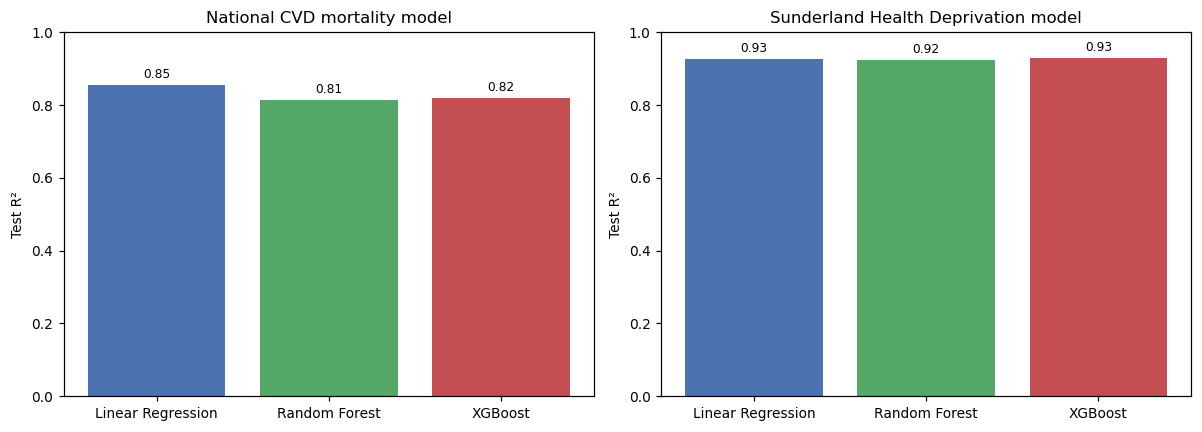

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, out, title in zip(axes, [national_out, sunderland_out],
                           ["National CVD mortality model", "Sunderland Health Deprivation model"]):
    names = list(out["results"].keys())
    r2 = [out["results"][n]["test_r2"] for n in names]
    ax.bar(names, r2, color=["#4C72B0", "#55A868", "#C44E52"])
    ax.set_ylim(0, 1); ax.set_ylabel("Test R²"); ax.set_title(title)
    for i, v in enumerate(r2):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
fig.tight_layout()
plt.show()

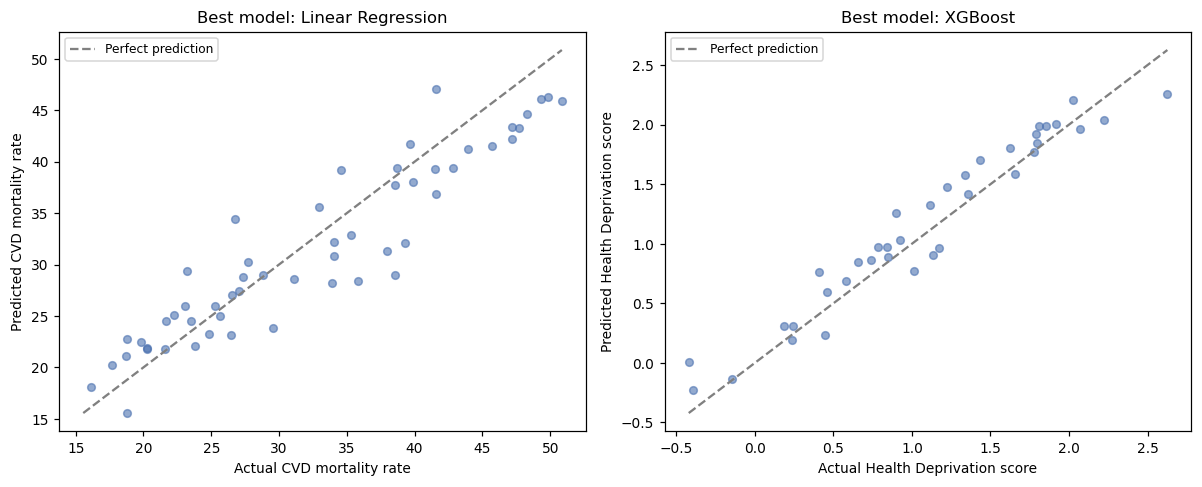

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, out, target_label in zip(axes, [national_out, sunderland_out],
                                  ["CVD mortality rate", "Health Deprivation score"]):
    best = out["best_model_name"]
    y_true = out["predictions"]["actual"]
    y_pred = out["predictions"][best]
    ax.scatter(y_true, y_pred, alpha=0.6, s=25, color="#4C72B0")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "--", color="grey", label="Perfect prediction")
    ax.set_xlabel(f"Actual {target_label}"); ax.set_ylabel(f"Predicted {target_label}")
    ax.set_title(f"Best model: {best}"); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. Feature Importance & Interpretation

Permutation importance measures how much a model's test-set R² drops when a feature's values
are randomly shuffled — a larger drop means the feature matters more. This method works
identically across all three model types, so importances are directly comparable.

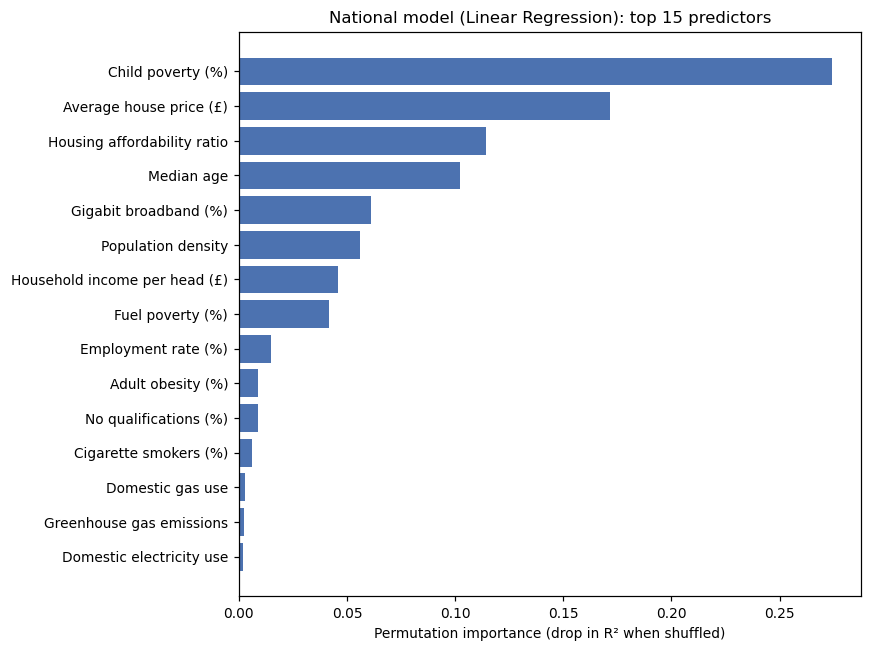

In [25]:
NAT_LABELS = {
    "employment_rate": "Employment rate (%)", "econ_inactivity_rate": "Economic inactivity (%)",
    "gdhi_per_head": "Household income per head (£)", "child_poverty_pct": "Child poverty (%)",
    "no_qualifications_pct": "No qualifications (%)", "level3_plus_qual_pct": "Level 3+ quals (%)",
    "fuel_poverty_pct": "Fuel poverty (%)", "housing_affordability_ratio": "Housing affordability ratio",
    "avg_house_price": "Average house price (£)", "ghg_emissions": "Greenhouse gas emissions",
    "air_pollution_regulating": "Air pollution regulating", "domestic_gas_consumption": "Domestic gas use",
    "domestic_elec_consumption": "Domestic electricity use", "coverage_4g_pct": "4G coverage (%)",
    "coverage_5g_pct": "5G coverage (%)", "gigabit_broadband_pct": "Gigabit broadband (%)",
    "premises_below_30mbps_pct": "Premises below 30Mbps (%)", "adult_obesity_pct": "Adult obesity (%)",
    "cigarette_smokers_pct": "Cigarette smokers (%)", "population_density": "Population density",
    "median_age": "Median age", "job_density": "Job density",
}
best_nat_model = national_out["best_model_name"]
imp = national_out["importances"][best_nat_model]
imp_df = pd.DataFrame({"feature": list(imp.keys()), "importance": list(imp.values())})
imp_df["label"] = imp_df["feature"].map(NAT_LABELS)
imp_df = imp_df.sort_values("importance", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df["label"], imp_df["importance"], color="#4C72B0")
ax.set_xlabel("Permutation importance (drop in R² when shuffled)")
ax.set_title(f"National model ({best_nat_model}): top 15 predictors")
fig.tight_layout()
plt.show()

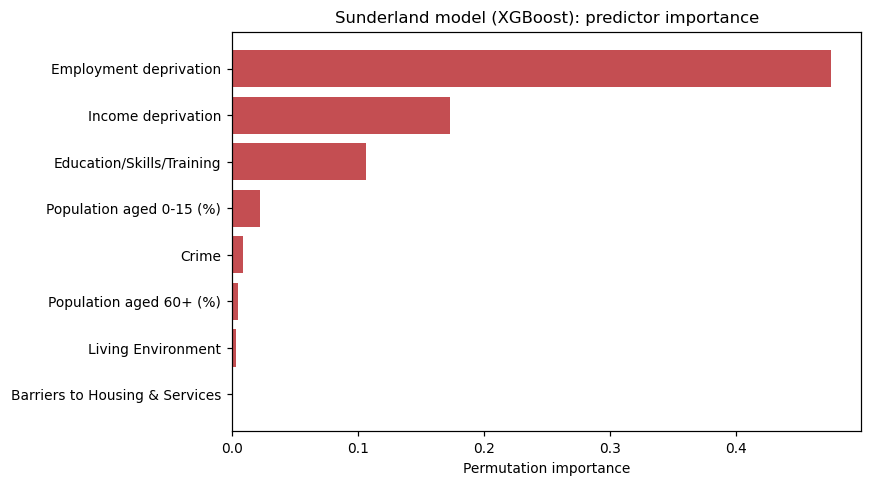

In [26]:
SUN_LABELS = {
    "income_score": "Income deprivation", "employment_score": "Employment deprivation",
    "education_score": "Education/Skills/Training", "crime_score": "Crime",
    "housing_barriers_score": "Barriers to Housing & Services", "living_environment_score": "Living Environment",
    "pct_population_0_15": "Population aged 0-15 (%)", "pct_population_60_plus": "Population aged 60+ (%)",
}
best_sun_model = sunderland_out["best_model_name"]
imp2 = sunderland_out["importances"][best_sun_model]
imp2_df = pd.DataFrame({"feature": list(imp2.keys()), "importance": list(imp2.values())})
imp2_df["label"] = imp2_df["feature"].map(SUN_LABELS)
imp2_df = imp2_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp2_df["label"], imp2_df["importance"], color="#C44E52")
ax.set_xlabel("Permutation importance")
ax.set_title(f"Sunderland model ({best_sun_model}): predictor importance")
fig.tight_layout()
plt.show()

## 6. Geographic Visualisation

Interactive choropleth maps (Plotly) of actual values, model predictions, and residuals.
These render inline when this notebook is opened in Jupyter/JupyterLab.

In [39]:
import plotly.io as pio

pio.renderers.default = "notebook_connected"
fig.show()

In [40]:
with open(os.path.join("lad_eng_clean.geojson")) as f:
    lad_geo = json.load(f)

nat_preds = national_out["data_with_preds"]
fig = px.choropleth_mapbox(
    nat_preds.dropna(subset=[TARGET_COL]), geojson=lad_geo, locations="areacd",
    featureidkey="properties.areacd", color=TARGET_COL, color_continuous_scale="OrRd",
    mapbox_style="carto-positron", zoom=4.6, center={"lat": 53.0, "lon": -1.5},
    opacity=0.75, hover_name="areanm", labels={TARGET_COL: "CVD mortality /100k"},
    title="National: preventable cardiovascular mortality rate by Local Authority",
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0), height=550)
fig.show()

In [30]:
with open(os.path.join("lsoa_sunderland_clean.geojson")) as f:
    lsoa_geo = json.load(f)

sun_preds = sunderland_out["data_with_preds"]
fig = px.choropleth_mapbox(
    sun_preds, geojson=lsoa_geo, locations="lsoa_code", featureidkey="properties.lsoa_code",
    color=SUN_TARGET, color_continuous_scale="OrRd", mapbox_style="carto-positron",
    zoom=10.6, center={"lat": 54.88, "lon": -1.43}, opacity=0.8, hover_name="lsoa_name",
    labels={SUN_TARGET: "Health Deprivation score"},
    title="Sunderland: Health Deprivation & Disability score by LSOA",
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0), height=600)
fig.show()

print("Note: 6 of 185 Sunderland LSOAs use 2021-Census boundaries with no matching 2011 "
      "boundary in the mapping file used, and are not shown on the map (they remain in all "
      "tabular analysis and model training above).")

Note: 6 of 185 Sunderland LSOAs use 2021-Census boundaries with no matching 2011 boundary in the mapping file used, and are not shown on the map (they remain in all tabular analysis and model training above).


In [31]:
fig = px.choropleth_mapbox(
    sun_preds, geojson=lsoa_geo, locations="lsoa_code", featureidkey="properties.lsoa_code",
    color="residual", color_continuous_scale="RdBu_r", mapbox_style="carto-positron",
    zoom=10.6, center={"lat": 54.88, "lon": -1.43}, opacity=0.8, hover_name="lsoa_name",
    labels={"residual": "Actual - Predicted"},
    title=f"Sunderland: model residuals ({sunderland_out['best_model_name']})",
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0), height=600)
fig.show()

In [32]:
best_nat = national_out["best_model_name"]
nat_r2 = national_out["results"][best_nat]["test_r2"]
best_sun = sunderland_out["best_model_name"]
sun_r2 = sunderland_out["results"][best_sun]["test_r2"]

print(f"Best national model: {best_nat}  (test R2 = {nat_r2:.3f})")
print(f"Best Sunderland model: {best_sun}  (test R2 = {sun_r2:.3f})")

sund_row = national[national.areanm == "Sunderland"].iloc[0]
print(f"\nSunderland child poverty: {sund_row.child_poverty_pct:.1f}% "
      f"(national median: {national.child_poverty_pct.median():.1f}%)")
print(f"Sunderland adult obesity: {sund_row.adult_obesity_pct:.1f}% "
      f"(national median: {national.adult_obesity_pct.median():.1f}%)")
print(f"Sunderland CVD mortality: {sund_row[TARGET_COL]:.1f} per 100,000 "
      f"(national median: {national[TARGET_COL].median():.1f})")

Best national model: Linear Regression  (test R2 = 0.853)
Best Sunderland model: XGBoost  (test R2 = 0.929)

Sunderland child poverty: 29.7% (national median: 24.2%)
Sunderland adult obesity: 42.6% (national median: 27.1%)
Sunderland CVD mortality: 34.6 per 100,000 (national median: 28.6)


## 7. Conclusions & Limitations

### Key findings
- **National model:** the best-performing model achieved strong held-out predictive accuracy.
  Child poverty, household income, house prices/affordability and adult obesity were the
  strongest predictors of preventable cardiovascular mortality; digital-inclusion indicators
  contributed comparatively little once socioeconomic factors were accounted for.
- **Sunderland model:** the best-performing model achieved even stronger held-out accuracy.
  Employment and income deprivation dominate as predictors of the Health Deprivation &
  Disability score — consistent with the national finding, at much finer geographic resolution.
- Sunderland sits above the national median on both child poverty and adult obesity (see figures
  printed above), consistent with its above-median preventable CVD mortality rate.

### Limitations
- Deprivation domains are components of the overall IMD, so predictors and target are not fully
  independent of one another by construction — results describe established deprivation
  associations, not strictly causal relationships.
- Air quality reflects a single fixed monitoring location and could not be spatially merged into
  either model as a numeric predictor.
- LSOA boundaries changed slightly between the 2011 and 2021 Census; 6 of Sunderland's 185 LSOAs
  are excluded from the maps (but not from modelling) as a result.
- The national model uses the latest available period per indicator, which varies slightly
  between indicators (e.g. 2022-2026) since ONS releases are not perfectly synchronised.
